# Порівняння оптимізаторів **SGD**, **RMSProp** і **Adam** на прикладі простої CNN

## Мета роботи
У цьому ноутбуці ми порівняємо три популярні оптимізатори:
- **SGD**
- **RMSProp**
- **Adam**

на задачі класифікації зображень за допомогою **простої згорткової нейронної мережі (CNN)**.

## Датасет
Використаємо **Fashion-MNIST**:
- 10 класів одягу
- зображення **28×28**
- 1 канал (grayscale)

## Що будемо порівнювати
- швидкість збіжності
- train / validation loss
- train / validation accuracy
- фінальну якість на test set
- час навчання

## Важлива умова
Щоб порівняння було коректним, ми залишаємо:
- однакову архітектуру CNN
- однакову кількість епох
- однаковий batch size

Змінюється **лише оптимізатор**.


In [116]:
import time
import numpy as np
import matplotlib.pyplot as plt

from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix

np.random.seed(42)
keras.utils.set_random_seed(42)


## 1. Завантаження та підготовка даних


In [117]:
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = x_train[..., None]
x_test = x_test[..., None]

print("x_train:", x_train.shape)
print("x_test :", x_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


x_train: (60000, 28, 28, 1)
x_test : (10000, 28, 28, 1)
y_train: (60000,)
y_test : (10000,)


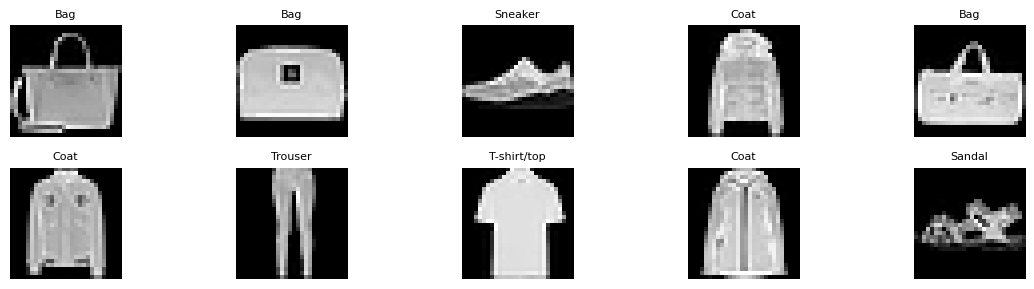

In [118]:
idx = np.random.choice(len(x_train), 10, replace=False)

plt.figure(figsize=(12, 3))
for i, j in enumerate(idx, start=1):
    plt.subplot(2, 5, i)
    plt.imshow(x_train[j].squeeze(), cmap="gray")
    plt.title(class_names[y_train[j]], fontsize=8)
    plt.axis("off")
plt.tight_layout()
plt.show()


## 2. Проста CNN для експерименту

Архітектура:
- `Conv2D(32, 3x3, relu)`
- `MaxPooling2D(2x2)`
- `Conv2D(64, 3x3, relu)`
- `MaxPooling2D(2x2)`
- `Flatten`
- `Dense(128, relu)`
- `Dense(10, softmax)`


In [119]:
def build_cnn():
    model = keras.Sequential([
        keras.Input(shape=(28, 28, 1)),
        layers.Conv2D(32, kernel_size=(3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Conv2D(64, kernel_size=(3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dense(10, activation="softmax")
    ], name="simple_cnn")
    return model

cnn = build_cnn()
cnn.summary()


Model: "simple_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_60 (Conv2D)                   │ (None, 28, 28, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_60 (MaxPooling2D)      │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_61 (Conv2D)                   │ (None, 14, 14, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_61 (MaxPooling2D)      │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_30 (Flatten)                 │ (None, 3136)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_60 (Dense)                     │ (None, 128)                 │         401,536 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_61 (Dense)                     │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

## 3. Функція навчання моделі з довільним оптимізатором


In [120]:
def train_with_optimizer(optimizer, optimizer_name, epochs=8, batch_size=128):
    model = build_cnn()

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    start = time.time()
    history = model.fit(
        x_train, y_train,
        validation_split=0.1,
        epochs=epochs,
        batch_size=batch_size,
        verbose=1,
    )
    elapsed = time.time() - start

    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

    return {
        "name": optimizer_name,
        "history": history.history,
        "test_loss": float(test_loss),
        "test_acc": float(test_acc),
        "train_time_sec": float(elapsed),
        "model": model
    }


## 4. Навчання CNN з різними оптимізаторами


In [121]:
EPOCHS = 12
BATCH_SIZE = 128

sgd_result = train_with_optimizer(
    keras.optimizers.SGD(learning_rate=0.01),
    "SGD",
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

rmsprop_result = train_with_optimizer(
    keras.optimizers.RMSprop(learning_rate=0.001),
    "RMSProp",
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
)

adam_result = train_with_optimizer(
    keras.optimizers.Adam(learning_rate=0.001),
    "Adam",
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)


Epoch 1/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.5824 - loss: 1.3232 - val_accuracy: 0.7598 - val_loss: 0.7033
Epoch 2/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.7528 - loss: 0.6847 - val_accuracy: 0.7887 - val_loss: 0.5939
Epoch 3/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.7844 - loss: 0.5951 - val_accuracy: 0.8048 - val_loss: 0.5428
Epoch 4/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8033 - loss: 0.5431 - val_accuracy: 0.8192 - val_loss: 0.5058
Epoch 5/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.8170 - loss: 0.5043 - val_accuracy: 0.8298 - val_loss: 0.4782
Epoch 6/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.8290 - loss: 0.4742 - val_accuracy: 0.8383 - val_loss: 0.4566
Epoch 7/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8389 - loss: 0.4505 - val_accuracy: 0.8422 - val_loss: 0.4400
Epoch 8/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8465 - loss: 0.4313 - val_accu

## 5. Графіки навчання


In [122]:
results = [sgd_result, rmsprop_result, adam_result]


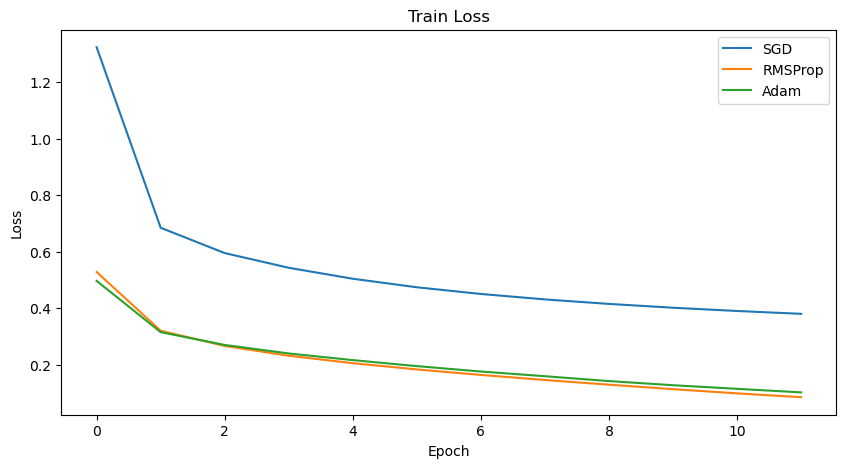

In [123]:
plt.figure(figsize=(10, 5))
for res in results:
    plt.plot(res["history"]["loss"], label=res["name"])
plt.title("Train Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


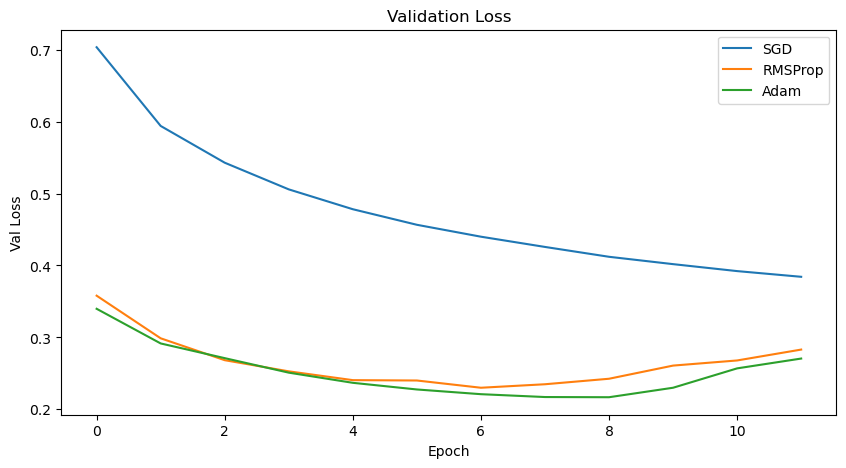

In [124]:
plt.figure(figsize=(10, 5))
for res in results:
    plt.plot(res["history"]["val_loss"], label=res["name"])
plt.title("Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Val Loss")
plt.legend()
plt.show()


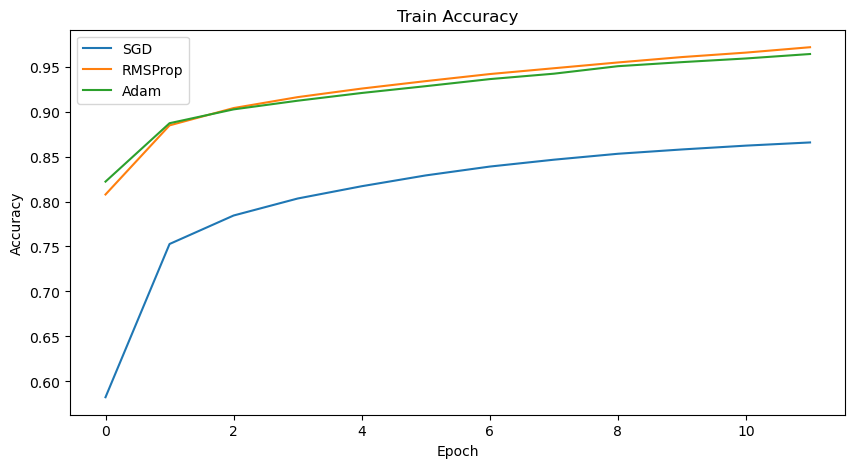

In [125]:
plt.figure(figsize=(10, 5))
for res in results:
    plt.plot(res["history"]["accuracy"], label=res["name"])
plt.title("Train Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


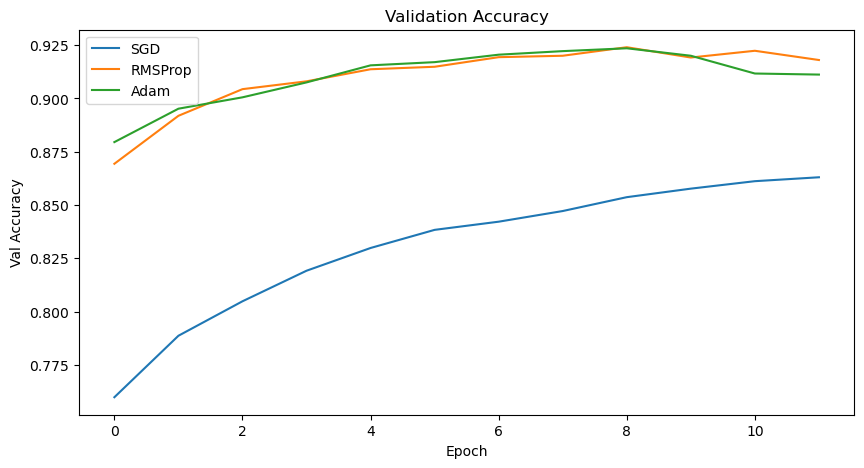

In [126]:
plt.figure(figsize=(10, 5))
for res in results:
    plt.plot(res["history"]["val_accuracy"], label=res["name"])
plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Val Accuracy")
plt.legend()
plt.show()


## 6. Підсумкова таблиця результатів


In [127]:
summary = []
for res in results:
    summary.append({
        "Optimizer": res["name"],
        "Final train loss": round(res["history"]["loss"][-1], 4),
        "Final val loss": round(res["history"]["val_loss"][-1], 4),
        "Final train acc": round(res["history"]["accuracy"][-1], 4),
        "Final val acc": round(res["history"]["val_accuracy"][-1], 4),
        "Test loss": round(res["test_loss"], 4),
        "Test acc": round(res["test_acc"], 4),
        "Train time (sec)": round(res["train_time_sec"], 2)
    })

summary


[{'Optimizer': 'SGD',
  'Final train loss': 0.3803,
  'Final val loss': 0.3843,
  'Final train acc': 0.8657,
  'Final val acc': 0.863,
  'Test loss': 0.3974,
  'Test acc': 0.8599,
  'Train time (sec)': 64.54},
 {'Optimizer': 'RMSProp',
  'Final train loss': 0.0853,
  'Final val loss': 0.2831,
  'Final train acc': 0.9715,
  'Final val acc': 0.918,
  'Test loss': 0.3175,
  'Test acc': 0.914,
  'Train time (sec)': 64.82},
 {'Optimizer': 'Adam',
  'Final train loss': 0.1024,
  'Final val loss': 0.2706,
  'Final train acc': 0.964,
  'Final val acc': 0.9112,
  'Test loss': 0.3087,
  'Test acc': 0.9029,
  'Train time (sec)': 65.42}]

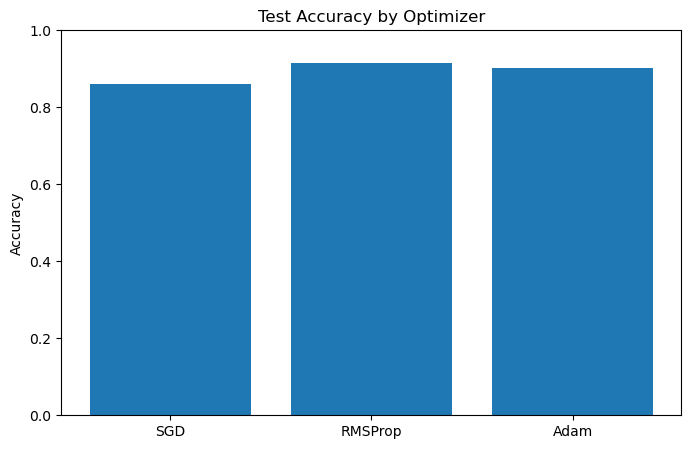

In [128]:
optimizers = [res["name"] for res in results]
test_accs = [res["test_acc"] for res in results]

plt.figure(figsize=(8, 5))
plt.bar(optimizers, test_accs)
plt.title("Test Accuracy by Optimizer")
plt.ylabel("Accuracy")
plt.ylim(0, 1.0)
plt.show()


## 7. Детальний аналіз для найкращого оптимізатора


In [129]:
best_result = max(results, key=lambda r: r["test_acc"])
print("Найкращий оптимізатор за test accuracy:", best_result["name"])
print("Test accuracy:", round(best_result["test_acc"], 4))


Найкращий оптимізатор за test accuracy: RMSProp
Test accuracy: 0.914


In [130]:
best_model = best_result["model"]
y_prob = best_model.predict(x_test, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

print(classification_report(y_test, y_pred, target_names=class_names, digits=4))


              precision    recall  f1-score   support

 T-shirt/top     0.8155    0.9060    0.8584      1000
     Trouser     0.9949    0.9850    0.9899      1000
    Pullover     0.8384    0.8870    0.8620      1000
       Dress     0.9048    0.9120    0.9084      1000
        Coat     0.8526    0.8850    0.8685      1000
      Sandal     0.9773    0.9920    0.9846      1000
       Shirt     0.8378    0.6610    0.7390      1000
     Sneaker     0.9505    0.9790    0.9645      1000
         Bag     0.9840    0.9810    0.9825      1000
  Ankle boot     0.9876    0.9520    0.9695      1000

    accuracy                         0.9140     10000
   macro avg     0.9143    0.9140    0.9127     10000
weighted avg     0.9143    0.9140    0.9127     10000



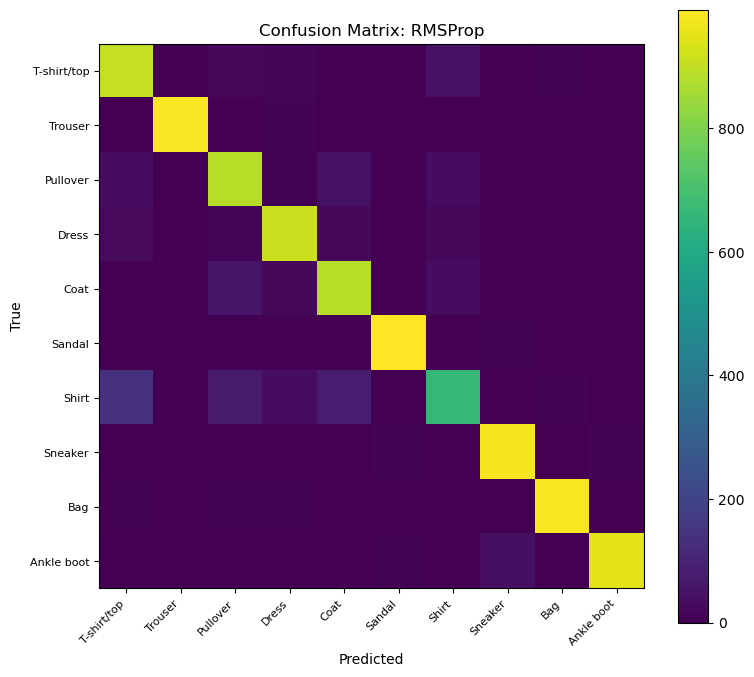

In [131]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 7))
plt.imshow(cm)
plt.title(f"Confusion Matrix: {best_result['name']}")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(range(10), class_names, rotation=45, ha="right", fontsize=8)
plt.yticks(range(10), class_names, fontsize=8)
plt.colorbar()
plt.tight_layout()
plt.show()


## 8. Інтерпретація результатів

Зверніть увагу на:
1. Який оптимізатор найшвидше знижує `loss`?
2. Який оптимізатор найшвидше підвищує `accuracy`?
3. Чи є ознаки overfitting?
4. Чи збігаються результати на validation і test?
5. Чи завжди швидша збіжність означає кращу фінальну якість?

### Типові спостереження
- **SGD** часто навчається повільніше, але після тюнінгу може давати сильні результати
- **RMSProp** часто стабільно і швидко зменшує loss
- **Adam** зазвичай є найзручнішим baseline для швидкого старту


# TO DO для студентів

## Завдання 1
Змініть `learning_rate` для кожного оптимізатора:
- SGD: `0.1`, `0.01`, `0.001`
- RMSProp: `0.001`, `0.0005`
- Adam: `0.001`, `0.0005`, `0.0001`

## Завдання 2
Додайте до SGD:
- `momentum=0.9`

Порівняйте:
- SGD
- SGD + momentum
- RMSProp
- Adam

## Завдання 3
Додайте `Dropout(0.3)` перед останнім Dense-шаром.

## Завдання 4
Додайте callbacks:
- `EarlyStopping`
- `ReduceLROnPlateau`
  
Та змініть кількість епох з 12 на 15


## 9. Заготовка для експерименту з callbacks


In [132]:
# early_stop = keras.callbacks.EarlyStopping(
#     monitor="val_loss",
#     mode="min",
#     patience=3,
#     restore_best_weights=True
# )

# reduce_lr = keras.callbacks.ReduceLROnPlateau(
#     monitor="val_loss",
#     mode="min",
#     factor=0.5,
#     patience=2,
#     min_lr=1e-5
# )

# model = build_cnn()
# model.compile(
#     optimizer=keras.optimizers.Adam(learning_rate=0.001),
#     loss="sparse_categorical_crossentropy",
#     metrics=["accuracy"]
# )

# history = model.fit(
#     x_train, y_train,
#     validation_split=0.1,
#     epochs=15,
#     batch_size=128,
#     callbacks=[early_stop, reduce_lr]
# )


# Висновок

У цьому ноутбуці ми порівняли **SGD**, **RMSProp** та **Adam** на прикладі простої CNN.

## Основні висновки
- оптимізатор суттєво впливає на швидкість збіжності
- одна й та сама CNN може поводитися по-різному залежно від optimizer
- **Adam** часто є сильним стартовим baseline
- **RMSProp** теж може показувати дуже хорошу збіжність
- **SGD** є важливим для розуміння базової оптимізації та може бути сильним після тюнінгу learning rate і momentum
